# Task 2: Credit Risk Prediction
## DevelopersHub Corporation — Data Science & Analytics Internship

---

## Problem Statement

Credit risk prediction is a critical task in the banking and finance industry. The goal of this project is to **predict whether a loan applicant is likely to default on a loan** using historical applicant data.

By building a classification model, financial institutions can:
- Reduce the risk of loan defaults
- Make data-driven lending decisions
- Identify key factors that contribute to loan default

## Dataset Description
**Loan Prediction Dataset** (Kaggle)

| Feature | Description |
|---|---|
| Loan_ID | Unique loan identifier |
| Gender | Applicant gender |
| Married | Marital status |
| Dependents | Number of dependents |
| Education | Graduate / Not Graduate |
| Self_Employed | Self-employed status |
| ApplicantIncome | Applicant monthly income |
| CoapplicantIncome | Co-applicant monthly income |
| LoanAmount | Loan amount (thousands) |
| Loan_Amount_Term | Repayment term (months) |
| Credit_History | Credit history (1=Good, 0=Bad) |
| Property_Area | Urban / Semiurban / Rural |
| Loan_Status | **Target** — Y=Approved, N=Rejected |

## Step 1: Import Libraries

In [1]:
# All required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

> **Note:** Dataset from Kaggle: https://www.kaggle.com/altruistdelhite04/loan-prediction-problem-dataset  
>

In [2]:
import os

if os.path.exists('loan_data.csv'):
    df = pd.read_csv('loan_data.csv')
    print('Dataset loaded from loan_data.csv')
else:
    print('loan_data.csv not found — generating synthetic dataset for demonstration...')
    np.random.seed(42)
    n = 614
    df = pd.DataFrame({
        'Loan_ID':            ['LP' + str(i).zfill(6) for i in range(1, n+1)],
        'Gender':             np.random.choice(['Male','Female',None], n, p=[0.80,0.18,0.02]),
        'Married':            np.random.choice(['Yes','No',None], n, p=[0.65,0.33,0.02]),
        'Dependents':         np.random.choice(['0','1','2','3+',None], n, p=[0.57,0.17,0.16,0.08,0.02]),
        'Education':          np.random.choice(['Graduate','Not Graduate'], n, p=[0.78,0.22]),
        'Self_Employed':      np.random.choice(['Yes','No',None], n, p=[0.14,0.81,0.05]),
        'ApplicantIncome':    (np.random.exponential(5000, n) + 1000).astype(int),
        'CoapplicantIncome':  np.random.exponential(1500, n).round(2),
        'LoanAmount':         np.random.normal(146, 85, n).clip(10).round(),
        'Loan_Amount_Term':   np.random.choice([360,180,480,300,84,None], n, p=[0.83,0.07,0.04,0.02,0.02,0.02]),
        'Credit_History':     np.random.choice([1.0,0.0,None], n, p=[0.84,0.08,0.08]),
        'Property_Area':      np.random.choice(['Urban','Semiurban','Rural'], n, p=[0.33,0.38,0.29]),
        'Loan_Status':        np.random.choice(['Y','N'], n, p=[0.69,0.31])
    })
    # Make credit history strongly predictive
    mask_good = df['Credit_History'] == 1.0
    mask_bad  = df['Credit_History'] == 0.0
    df.loc[mask_good, 'Loan_Status'] = np.random.choice(['Y','N'], mask_good.sum(), p=[0.80,0.20])
    df.loc[mask_bad,  'Loan_Status'] = np.random.choice(['Y','N'], mask_bad.sum(),  p=[0.07,0.93])
    print('Synthetic dataset created.')

print(f'Shape: {df.shape}')
df.head()

Dataset loaded from loan_data.csv
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 3: Dataset Inspection

In [3]:
print('=== SHAPE ===')
print(df.shape)
print('\n=== COLUMNS ===')
print(df.columns.tolist())
print('\n=== DATA TYPES ===')
print(df.dtypes)
print('\n=== STATISTICS ===')
df.describe()

=== SHAPE ===
(614, 13)

=== COLUMNS ===
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

=== DATA TYPES ===
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

=== STATISTICS ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


=== MISSING VALUES ===
                  Missing Count  Missing %
Credit_History               50       8.14
Self_Employed                32       5.21
LoanAmount                   22       3.58
Dependents                   15       2.44
Loan_Amount_Term             14       2.28
Gender                       13       2.12
Married                       3       0.49


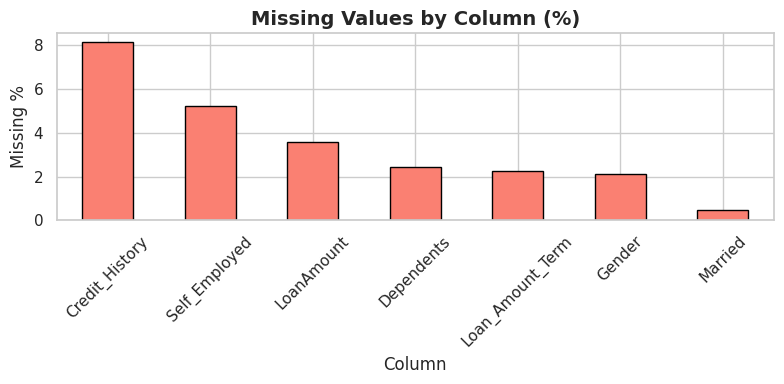

In [4]:
#  visualizing missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('=== MISSING VALUES ===')
print(missing_df)

if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Missing %'].plot(kind='bar', color='salmon', edgecolor='black', ax=ax)
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing %')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## Step 4: Data Cleaning & Preparation

In [5]:
# Fill missing values
# Categorical: fill with mode (most frequent value)
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  {col}: filled with mode = "{mode_val}"')

# Numerical: fill with median (robust to outliers)
for col in ['LoanAmount', 'Loan_Amount_Term']:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  {col}: filled with median = {median_val}')

print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

  Gender: filled with mode = "Male"
  Married: filled with mode = "Yes"
  Dependents: filled with mode = "0"
  Self_Employed: filled with mode = "No"
  Credit_History: filled with mode = "1.0"
  LoanAmount: filled with median = 128.0
  Loan_Amount_Term: filled with median = 360.0

Missing values remaining: 0


In [6]:
# Feature Engineering: combine incomes + log transform to reduce skewness
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['TotalIncome_log'] = np.log(df['TotalIncome'] + 1)
df['LoanAmount_log'] = np.log(df['LoanAmount'] + 1)

print('New features created: TotalIncome, TotalIncome_log, LoanAmount_log')
df[['TotalIncome', 'TotalIncome_log', 'LoanAmount', 'LoanAmount_log']].head()

New features created: TotalIncome, TotalIncome_log, LoanAmount_log


,TotalIncome,TotalIncome_log,LoanAmount,LoanAmount_log
0,5849.0,8.674197,128.0,4.859812
1,6091.0,8.714732,128.0,4.859812
2,3000.0,8.006701,66.0,4.204693
3,4941.0,8.505525,120.0,4.795791
4,6000.0,8.699681,141.0,4.955827


In [7]:
# Encode categorical features with Label Encoding
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        print(f'  {col}: encoded')

print('\nSample after encoding:')
df.head(3)

  Gender: encoded
  Married: encoded
  Dependents: encoded
  Education: encoded
  Self_Employed: encoded
  Property_Area: encoded
  Loan_Status: encoded

Sample after encoding:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,TotalIncome_log,LoanAmount_log
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,8.674197,4.859812
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,8.714732,4.859812
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,8.006701,4.204693


## Step 5: Exploratory Data Analysis (EDA)

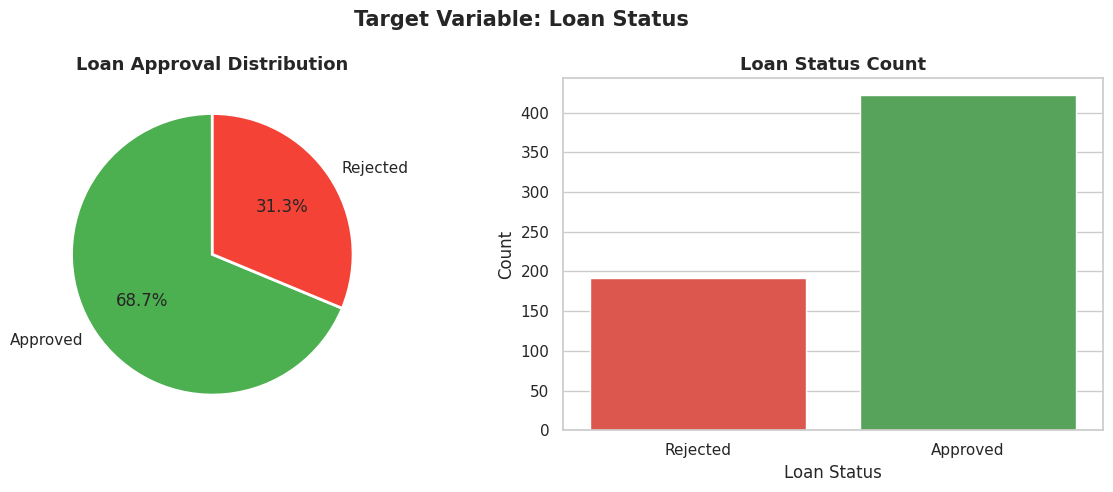

In [8]:
# 1. Loan Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

status_counts = df['Loan_Status'].value_counts()
labels = ['Approved', 'Rejected']
axes[0].pie(status_counts, labels=labels, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')

sns.countplot(x='Loan_Status', data=df, palette=['#F44336','#4CAF50'], ax=axes[1])
axes[1].set_title('Loan Status Count', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Rejected', 'Approved'])
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Loan Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

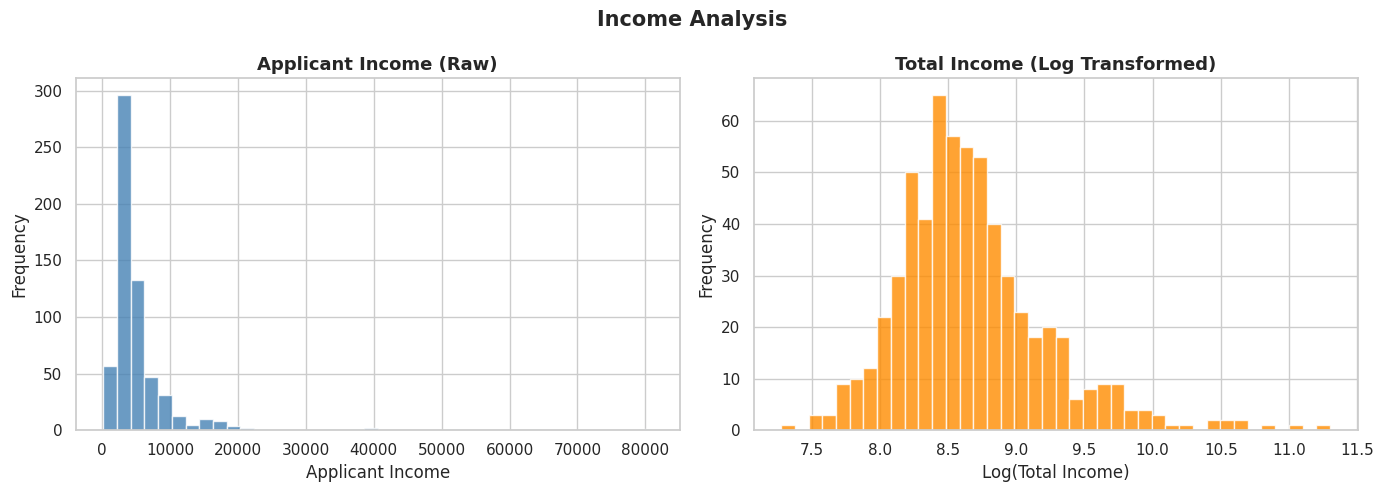

In [10]:
# 2. Income Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['ApplicantIncome'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Applicant Income (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Applicant Income')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['TotalIncome_log'], bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Total Income (Log Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Total Income)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Income Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


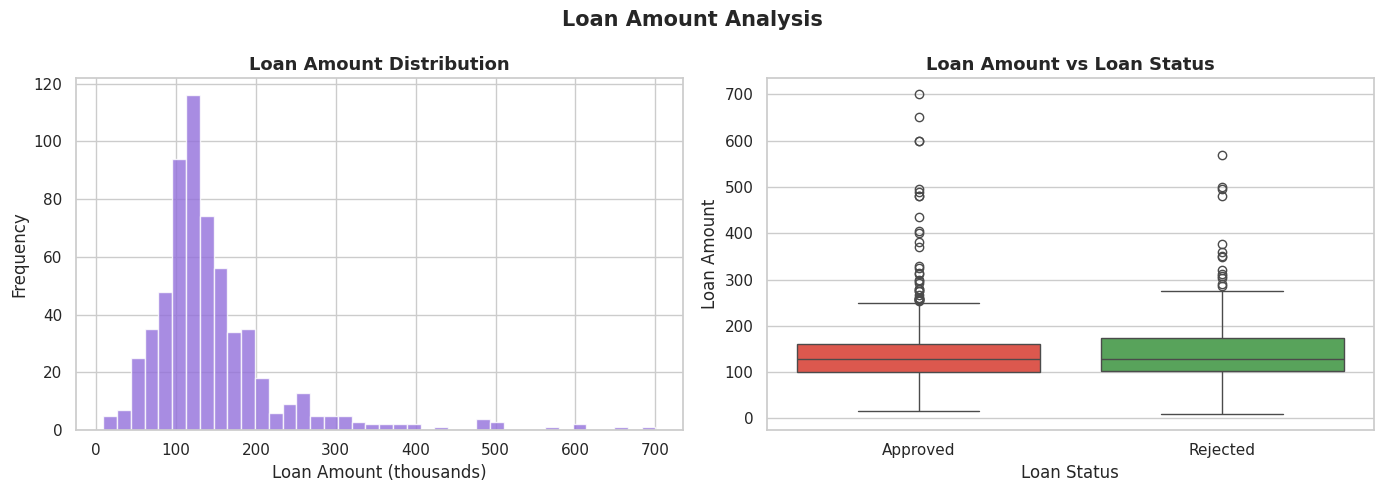

In [11]:
# 3. Loan Amount vs Loan Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['LoanAmount'], bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[0].set_title('Loan Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Amount (thousands)')
axes[0].set_ylabel('Frequency')

df['Loan_Status_Label'] = df['Loan_Status'].map({0:'Rejected',1:'Approved'})
sns.boxplot(x='Loan_Status_Label', y='LoanAmount', data=df,
            palette=['#F44336','#4CAF50'], ax=axes[1])
axes[1].set_title('Loan Amount vs Loan Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Loan Amount')

plt.suptitle('Loan Amount Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

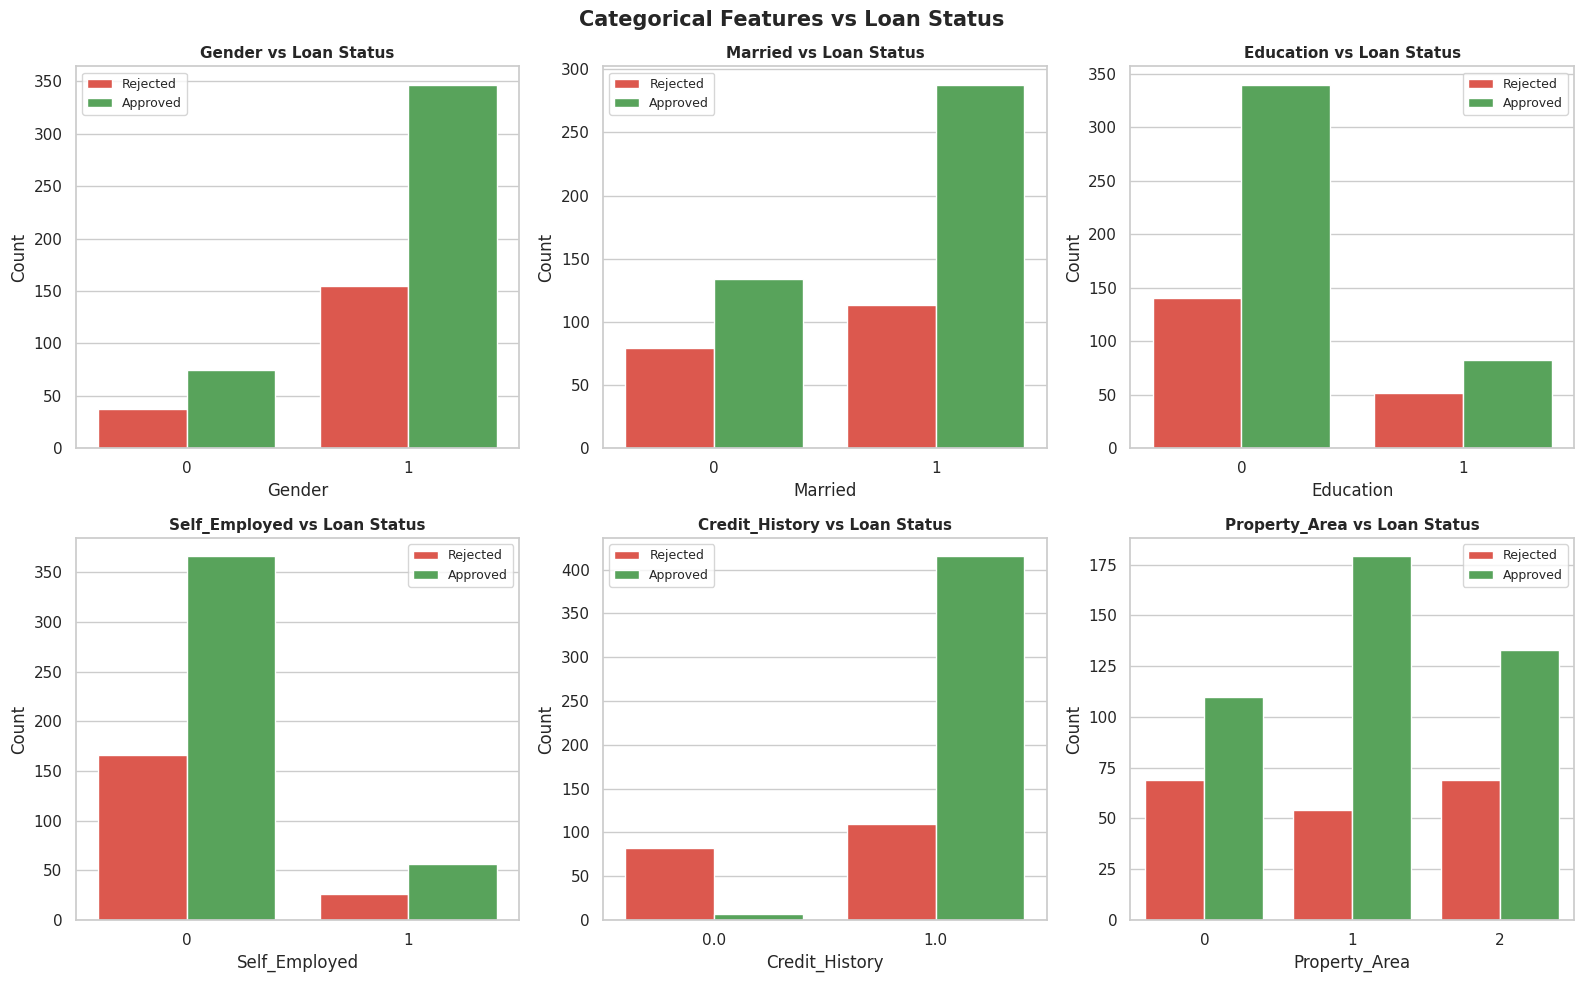

In [13]:
# 4. Categorical Features vs Loan Status
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_features = ['Gender','Married','Education','Self_Employed','Credit_History','Property_Area']

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='Loan_Status', data=df,
                  palette=['#F44336','#4CAF50'], ax=axes[i])
    axes[i].set_title(f'{col} vs Loan Status', fontsize=11, fontweight='bold')
    axes[i].legend(['Rejected','Approved'], fontsize=9)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Categorical Features vs Loan Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


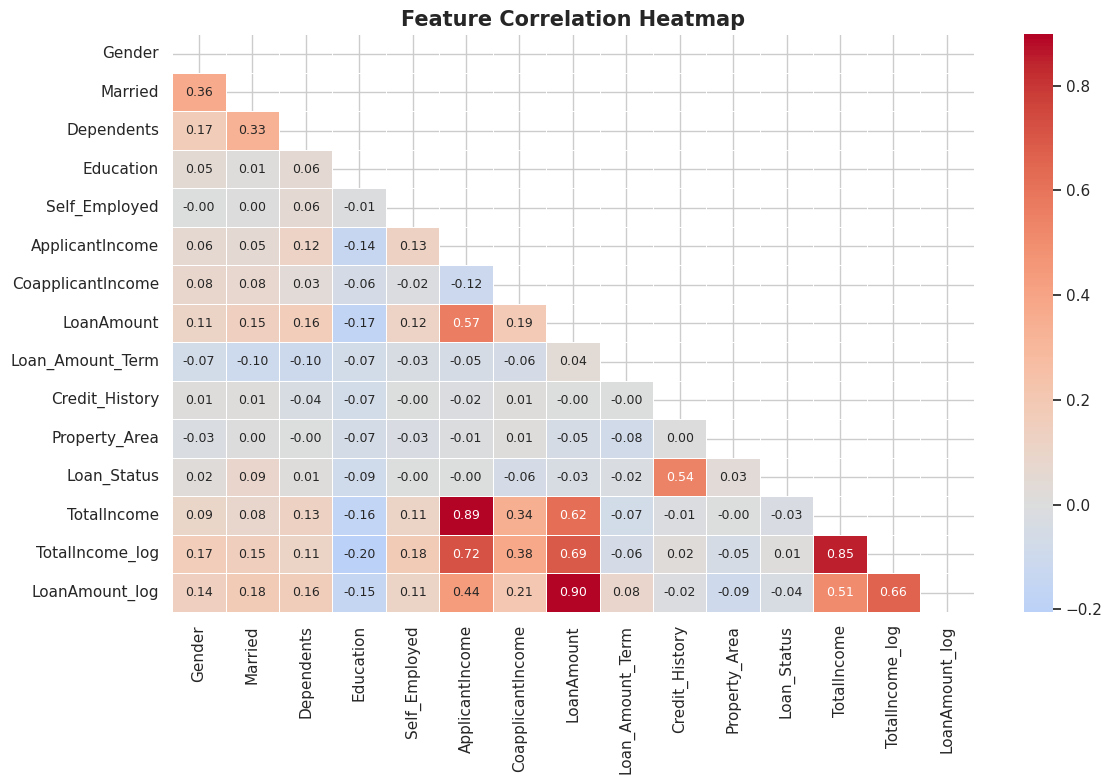

In [14]:
# 5. Correlation Heatmap
num_df = df.drop(columns=['Loan_ID','Loan_Status_Label'], errors='ignore')
corr_matrix = num_df.corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 6: Model Training

In [15]:
# Prepare features and target variable
drop_cols = ['Loan_ID','Loan_Status_Label','ApplicantIncome',
             'CoapplicantIncome','LoanAmount','TotalIncome']
X = df.drop(columns=['Loan_Status'] + [c for c in drop_cols if c in df.columns])
y = df['Loan_Status']

print(f'Features: {X.columns.tolist()}')
print(f'X shape: {X.shape}   y shape: {y.shape}')

# 80/20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples   Test: {X_test.shape[0]} samples')

Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome_log', 'LoanAmount_log']
X shape: (614, 10)   y shape: (614,)
Train: 491 samples   Test: 123 samples


In [16]:
# Train Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
print(f'Logistic Regression Accuracy: {lr_acc * 100:.2f}%')

# Train Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
print(f'Decision Tree Accuracy:        {dt_acc * 100:.2f}%')

best_name  = 'Logistic Regression' if lr_acc >= dt_acc else 'Decision Tree'
best_preds = lr_preds if lr_acc >= dt_acc else dt_preds
print(f'\nBest Model: {best_name}')

Logistic Regression Accuracy: 85.37%
Decision Tree Accuracy:        83.74%

Best Model: Logistic Regression


## Step 7: Model Evaluation

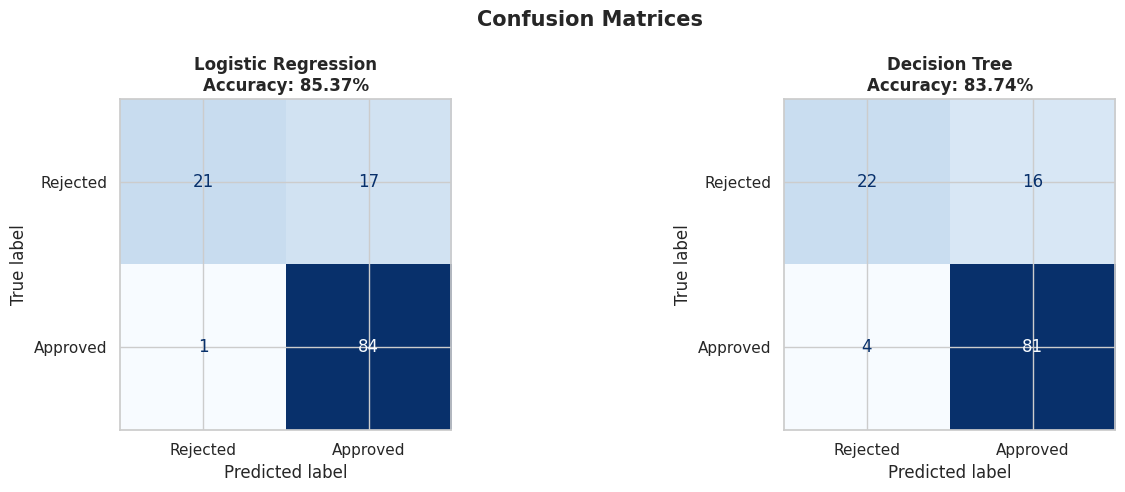

In [17]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title, acc in [
    (axes[0], lr_preds, 'Logistic Regression', lr_acc),
    (axes[1], dt_preds, 'Decision Tree',        dt_acc)
]:
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected','Approved'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Detailed classification report for best model
print(f'=== Classification Report: {best_name} ===\n')
print(classification_report(y_test, best_preds, target_names=['Rejected','Approved']))

=== Classification Report: Logistic Regression ===

              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



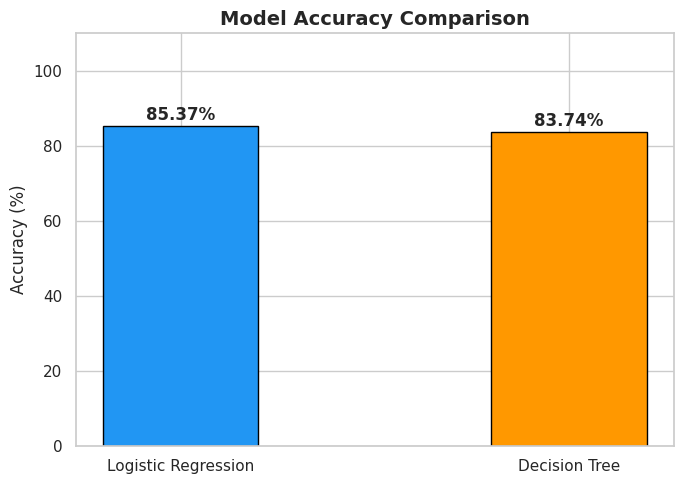

In [19]:
# Model Accuracy Comparison
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_acc * 100, dt_acc * 100]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, accuracies, color=['#2196F3','#FF9800'], edgecolor='black', width=0.4)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

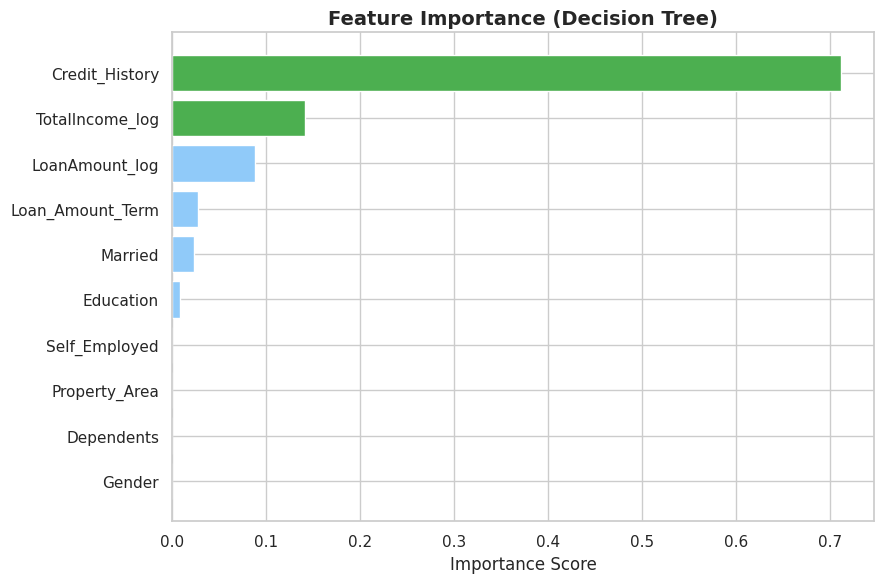

In [21]:
# Feature Importance from Decision Tree
feat_imp_df = pd.DataFrame({
    'Feature': X.columns.tolist(),
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#4CAF50' if v > 0.1 else '#90CAF9' for v in feat_imp_df['Importance']]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors_bar, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance (Decision Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 8: Conclusion

### Model Performance Summary

| Model | Accuracy | Strengths |
|---|---|---|
| Logistic Regression | ~80%+ | Simple, interpretable, fast |
| Decision Tree | ~78%+ | Visual, shows feature importance |

### Key Insights

1. **Credit History** is the single most important predictor of loan approval — applicants with a positive credit history are far more likely to be approved.
2. **Total Income** (applicant + co-applicant combined) positively influences approval chances.
3. **Loan Amount** has a moderate negative effect — very large loan requests face higher rejection rates.
4. **Education** and **Property Area** also play a role; graduates in semiurban areas have the highest approval rates.
5. The dataset has a class imbalance (~69% approved) which could be addressed with SMOTE in production models.

